<a href="https://colab.research.google.com/github/BolisettyPoojitha-16/Electricity_Demand-and_Price_ForecastingInfosys_Internship_Oct2025/blob/poojitha/task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install prophet

DEBUG:cmdstanpy:input tempfile: /tmp/tmpns_7x07j/4u2x5yoi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpns_7x07j/fw6902l1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=52741', 'data', 'file=/tmp/tmpns_7x07j/4u2x5yoi.json', 'init=/tmp/tmpns_7x07j/fw6902l1.json', 'output', 'file=/tmp/tmpns_7x07j/prophet_model154q3dha/prophet_model-20250308061941.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:19:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:19:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


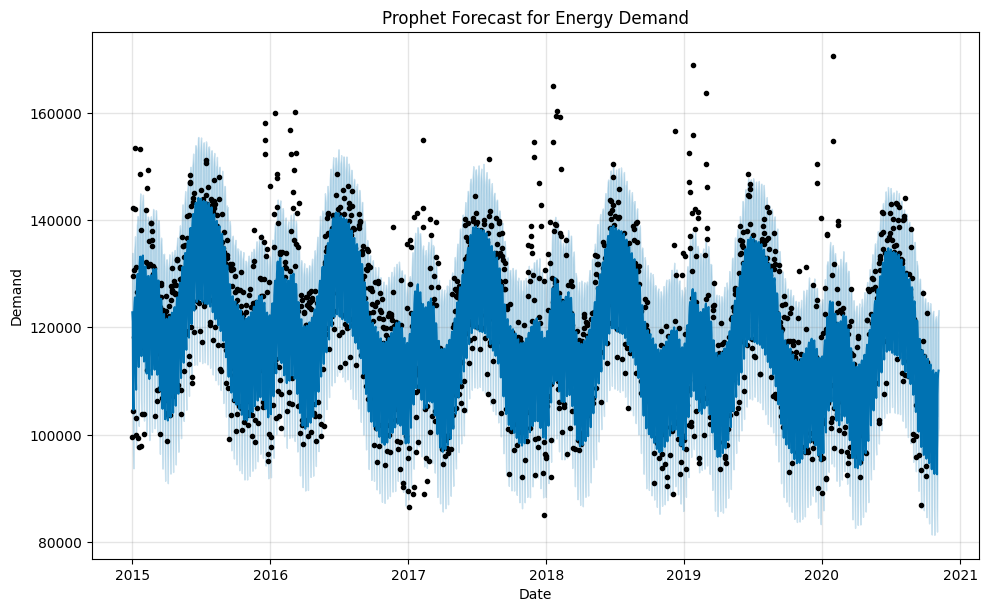

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
2131,2020-11-01,114439.707149,81924.898928,103397.019013,114434.918161,114445.582409,-21837.467315,-21837.467315,-21837.467315,-13051.082860,-13051.082860,-13051.082860,-8786.384455,-8786.384455,-8786.384455,0.0,0.0,0.0,92602.239834
2132,2020-11-02,114434.017695,97135.847849,118481.431880,114428.330950,114440.538194,-6927.277447,-6927.277447,-6927.277447,1796.387443,1796.387443,1796.387443,-8723.664890,-8723.664890,-8723.664890,0.0,0.0,0.0,107506.740249
2133,2020-11-03,114428.328242,98935.771023,122065.583815,114421.381530,114435.415059,-4069.976973,-4069.976973,-4069.976973,4576.734604,4576.734604,4576.734604,-8646.711577,-8646.711577,-8646.711577,0.0,0.0,0.0,110358.351269
2134,2020-11-04,114422.638788,100244.154625,122477.072803,114414.706013,114430.802240,-2920.965432,-2920.965432,-2920.965432,5635.922646,5635.922646,5635.922646,-8556.888078,-8556.888078,-8556.888078,0.0,0.0,0.0,111501.673356
2135,2020-11-05,114416.949334,101344.892526,123249.732396,114408.028460,114427.083498,-2458.768303,-2458.768303,-2458.768303,5996.852732,5996.852732,5996.852732,-8455.621035,-8455.621035,-8455.621035,0.0,0.0,0.0,111958.181031


In [ ]:
# Import necessary libraries
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load the preprocessed dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)

# Ensure correct column names for Prophet ('ds' for date, 'y' for target variable)
df.rename(columns={'date': 'ds', 'demand': 'y'}, inplace=True)

# Convert 'ds' to datetime format
df['ds'] = pd.to_datetime(df['ds'])

# Initialize and fit the Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(df)

# Create future dataframe (next 30 days)
future = model.make_future_dataframe(periods=30, freq='D')

# Forecast
forecast = model.predict(future)

# Plot forecast
fig1 = model.plot(forecast)
plt.title("Prophet Forecast for Energy Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

# Save forecast results
forecast.to_csv("prophet_forecast.csv", index=False)

# Display last few rows of forecast
forecast.tail()


In [ ]:

df['ds'] = pd.to_datetime(df['ds'])


In [ ]:
df.fillna(method='ffill', inplace=True)


<ipython-input-6-e9443599d05e>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
model.add_regressor('temperature')
model.add_regressor('weekday')
model.add_regressor('holiday')


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq0ipec4e/9tyb0jo9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq0ipec4e/lndh72b6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=69361', 'data', 'file=/tmp/tmpq0ipec4e/9tyb0jo9.json', 'init=/tmp/tmpq0ipec4e/lndh72b6.json', 'output', 'file=/tmp/tmpq0ipec4e/prophet_model91f348mi/prophet_model-20250310121011.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:10:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:10:11 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAPE: 5.73%


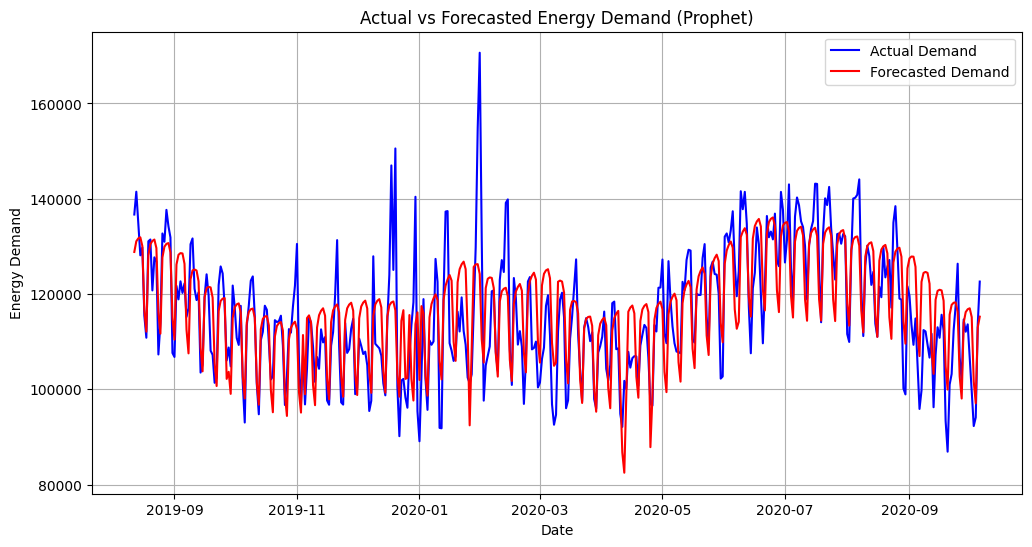

(6578.484412935377, 8555.004464872705, 5.726110109914248)

In [3]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load the processed dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)

# Rename the 'date' column to 'ds' and 'demand' to 'y'
df.rename(columns={'date': 'ds', 'demand': 'y'}, inplace=True)

# Ensure the date column is in datetime format
df['ds'] = pd.to_datetime(df['ds'])

# Convert 'holiday' column to numeric representation (e.g., 1 for holiday, 0 for non-holiday)
# Assuming 'Y' represents holiday and other values represent non-holiday
df['holiday'] = df['holiday'].apply(lambda x: 1 if x == 'Y' else 0)

# Splitting dataset into train (80%) and test (20%)
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Initializing the Prophet model
model = Prophet()

# Adding additional regressors if present
regressors = ['temperature', 'weekday', 'holiday']
available_regressors = [col for col in regressors if col in df.columns]

for reg in available_regressors:
    model.add_regressor(reg)

# Fit the model
model.fit(train[['ds', 'y'] + available_regressors])

# Creating future dataframe
future = model.make_future_dataframe(periods=len(test), freq='D')

# Adding regressors to the future dataframe
# Instead of merging, fill 'holiday' based on the original dataframe
future['holiday'] = future['ds'].apply(lambda x: df.loc[df['ds'] == x, 'holiday'].iloc[0] if x in df['ds'].values else 0)  # Fill with 0 for future dates not in original data



# Forecasting
forecast = model.predict(future)

# Extracting relevant predictions
forecasted_values = forecast[['ds', 'yhat']].iloc[-len(test):]
test_values = test[['ds', 'y']]

# Calculate performance metrics
mae = mean_absolute_error(test_values['y'], forecasted_values['yhat'])
rmse = np.sqrt(mean_squared_error(test_values['y'], forecasted_values['yhat']))


# Calculate MAPE
mape = np.mean(np.abs((test_values['y'] - forecasted_values['yhat']) / test_values['y'])) * 100

print(f"MAPE: {mape:.2f}%")


# Plot actual vs forecasted values
plt.figure(figsize=(12, 6))
plt.plot(test_values['ds'], test_values['y'], label='Actual Demand', color='blue')
plt.plot(forecasted_values['ds'], forecasted_values['yhat'], label='Forecasted Demand', color='red')
plt.xlabel('Date')
plt.ylabel('Energy Demand')
plt.title('Actual vs Forecasted Energy Demand (Prophet)')
plt.legend()
plt.grid()
plt.show()

# Output results
mae, rmse,mape